In [ ]:
#Multi-label classification for Gastro datasets by fine-tuning transformers, built based on https://github.com/NielsRogge/Transformers-Tutorials/blob/master/SigLIP/Fine_tuning_SigLIP_and_friends_for_multi_label_image_classification.ipynb

## **Set-up environment**

In [ ]:
#!pip install --upgrade transformers -q

In [1]:
import os
import cv2
import random
import torch
import numpy as np

from torch.utils.data import Dataset
from sklearn.preprocessing import MultiLabelBinarizer
from PIL import Image

## **Data preprocessing**

In [2]:
#Label and classes extraction
classes = ['mouth','esophagus','stomach','smallintestine','colon',
         'z_line','pylorus','ileocecalvalve','activebleeding','angiectasia',
        'blood','erosion','erythema','hematin','lymphangioectasis',
        'polyp','ulcer']


In [3]:
#Id to label and label to id for fine tune the model
id2label = {id: label for id, label in enumerate(classes)}
label2id = {v: k for k, v in id2label.items()}
print(id2label)
print(label2id)

{0: 'mouth', 1: 'esophagus', 2: 'stomach', 3: 'smallintestine', 4: 'colon', 5: 'z_line', 6: 'pylorus', 7: 'ileocecalvalve', 8: 'activebleeding', 9: 'angiectasia', 10: 'blood', 11: 'erosion', 12: 'erythema', 13: 'hematin', 14: 'lymphangioectasis', 15: 'polyp', 16: 'ulcer'}
{'mouth': 0, 'esophagus': 1, 'stomach': 2, 'smallintestine': 3, 'colon': 4, 'z_line': 5, 'pylorus': 6, 'ileocecalvalve': 7, 'activebleeding': 8, 'angiectasia': 9, 'blood': 10, 'erosion': 11, 'erythema': 12, 'hematin': 13, 'lymphangioectasis': 14, 'polyp': 15, 'ulcer': 16}


## **Model Load**

In [4]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from transformers import AutoModel, AutoProcessor

#select the pretraining model
model_id = "google/vit-base-patch16-224-in21k" # "google/siglip-so400m-patch14-384"
save_dir = "./pretrained/google/vit-base-patch16-224-in21k"

#processor = AutoImageProcessor.from_pretrained(model_id, use_fast=True)
#model = AutoModelForImageClassification.from_pretrained(model_id, problem_type="multi_label_classification", id2label=id2label,label2id=label2id)
#save pretrained model
#model.save_pretrained(save_dir)
#processor.save_pretrained(save_dir)
# Load saved pretrained model
model = AutoModelForImageClassification.from_pretrained(save_dir)
processor = AutoImageProcessor.from_pretrained(save_dir)

# Move the model to the appropriate device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [5]:
#show processing details in pre training model
processor

ViTImageProcessorFast {
  "data_format": "channels_first",
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessorFast",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [5]:
# handy utility I found at https://github.com/wenwei202/pytorch-examples/blob/ecbb7beb0fac13133c0b09ef980caf002969d315/imagenet/main.py#L296
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

### Load saved model

In [6]:
import torch

# Load the entire model
#model_save = torch.load('fine_tuned_vit-base-patch16-224-in21k.pth')
model_save = torch.load('fine_tuned_ep4.pth')

# Move the model to the appropriate device if necessary
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_save.to(device)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

## **Inference**

In [7]:
from pathlib import Path

def list_files(directory_path, recursive=False):
    """
    List all files in a given directory.
    
    :param directory_path: Path to the directory
    :param recursive: If True, includes files in subdirectories
    :return: List of file paths
    """
    try:
        dir_path = Path(directory_path).resolve()

        if not dir_path.exists():
            raise FileNotFoundError(f"Directory '{directory_path}' does not exist.")
        if not dir_path.is_dir():
            raise NotADirectoryError(f"'{directory_path}' is not a directory.")

        return [str(file) for file in dir_path.rglob('*.png') if file.is_file()]

    except Exception as e:
        print(f"Error: {e}")
        return []

In [8]:
#find all test samples
test_dir = 'Testdata_ICPR_2026_RARE_Challenge/ukdd_navi_00051/'
#test_dir = 'data/Galar_Frames_1_to_10/1'
test_paths = list_files(test_dir)
print('test-len=',len(test_paths))
test_no = len(test_paths)   #for train samples
print('test-no=',test_no)
print(test_paths[0])
print(test_paths[-1])


test-len= 44878
test-no= 44878
/mnt/e/Data/2026-RARE-Vision-Gastro/galar_dataset/notebooks/Testdata_ICPR_2026_RARE_Challenge/ukdd_navi_00051/frame_0000049.png
/mnt/e/Data/2026-RARE-Vision-Gastro/galar_dataset/notebooks/Testdata_ICPR_2026_RARE_Challenge/ukdd_navi_00051/frame_0044926.png


In [ ]:
# saving the predicted results for test data
import io
headers = ['frame_name', 'mouth','esophagus','stomach','smallintestine','colon',
         'z_line','pylorus','ileocecalvalve','activebleeding','angiectasia',
        'blood','erosion','erythema','hematin','lymphangioectasis',
        'polyp','ulcer']

arr_file_npy = 'pred_arr_00051_ep4.npy'
frame_npy = 'frames_00051_ep4.npy'
pred_npy = 'pred_00051_ep4.npy'
prob_npy = 'probs_00051_ep4.npy'
arr_file_txt = 'Multi-label-test-13Mar26.txt'
all_pred = []
all_frame = []
all_probs = []
thres = 0.49

for idx in range(test_no):
   # idx = idx0+16171-20
       # img = Image.open(train_list[idx])
    img = Image.open(test_paths[idx])
       # model_save.eval()   
         # prepare image for the model
    pixel_values = processor(img,return_tensors="pt").pixel_values.to(device)
        
    # forward pass
    with torch.no_grad():
        outputs = model_save(pixel_values)
        logits = outputs.logits
    
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(logits.squeeze().cpu())
   # print('idx,probs=',idx,probs)
        # select the probabilities > a certain threshold (e.g. 50%) as predicted
    predictions = np.zeros(probs.shape)
    #print(predictions)
    predictions[np.where(probs >= thres)] = 1 # turn predicted id's into actual label names
    if max(predictions)==0:
        max_val = max(probs)
       # print('max=', max_val)
        pos = [i for i, val in enumerate(probs) if val==max_val]
        predictions[pos] = 1 # Labeling at least 1 category
    all_pred.append(predictions)
    all_frame.append(test_paths[idx])
    all_probs.append(probs)
    #print(predictions)

arr2D = [all_frame, all_pred]
#print(arr2D)
np.save(pred_npy,all_pred)
np.save(frame_npy,all_frame)
#save probs
np.save(prob_npy,all_probs)
       # dt = [test_paths[idx][0]] + predictions

#save_to_csv('test.csv',headers,dt)
# loading saved files
#pred_list = np.load(pred_npy)
#print(pred_list[4000:4010])
#name_list = np.load(frame_npy[4000:4010])
#print(name_list)

#with open(arr_file_txt, 'r', encoding='utf-8') as file:
#            frame_list = file.read()  # Reads the entire file as a string
#print(frame_list)

In [ ]:
#Visualize the predictions

random_idx= [27652 16086 23377  3859  4718 13806  3200  8279  2356  6203 26683  1800
 26863  2341  8480 27294]
preds= [('smallintestine', tensor(1.0000)), ('angiectasia', tensor(0.0002)), ('lymphangioectasis', tensor(6.6999e-05))]
Truth= [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
preds= [('esophagus', tensor(0.9982)), ('smallintestine', tensor(0.0009)), ('colon', tensor(0.0008))]
Truth= [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
preds= [('colon', tensor(0.9997)), ('blood', tensor(8.6755e-05)), ('smallintestine', tensor(7.8817e-05))]
Truth= [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
preds= [('smallintestine', tensor(0.9996)), ('activebleeding', tensor(0.9993)), ('ileocecalvalve', tensor(0.9642))]
Truth= [0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0]
preds= [('smallintestine', tensor(1.0000)), ('angiectasia', tensor(0.0003)), ('blood', tensor(0.0002))]
Truth= [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
preds= [('smallintestine', tensor(1.0000)), ('lymphangioectasis', tensor(7.2891e-05)), ('angiectasia', tensor(5.1625e-05))]
Tr

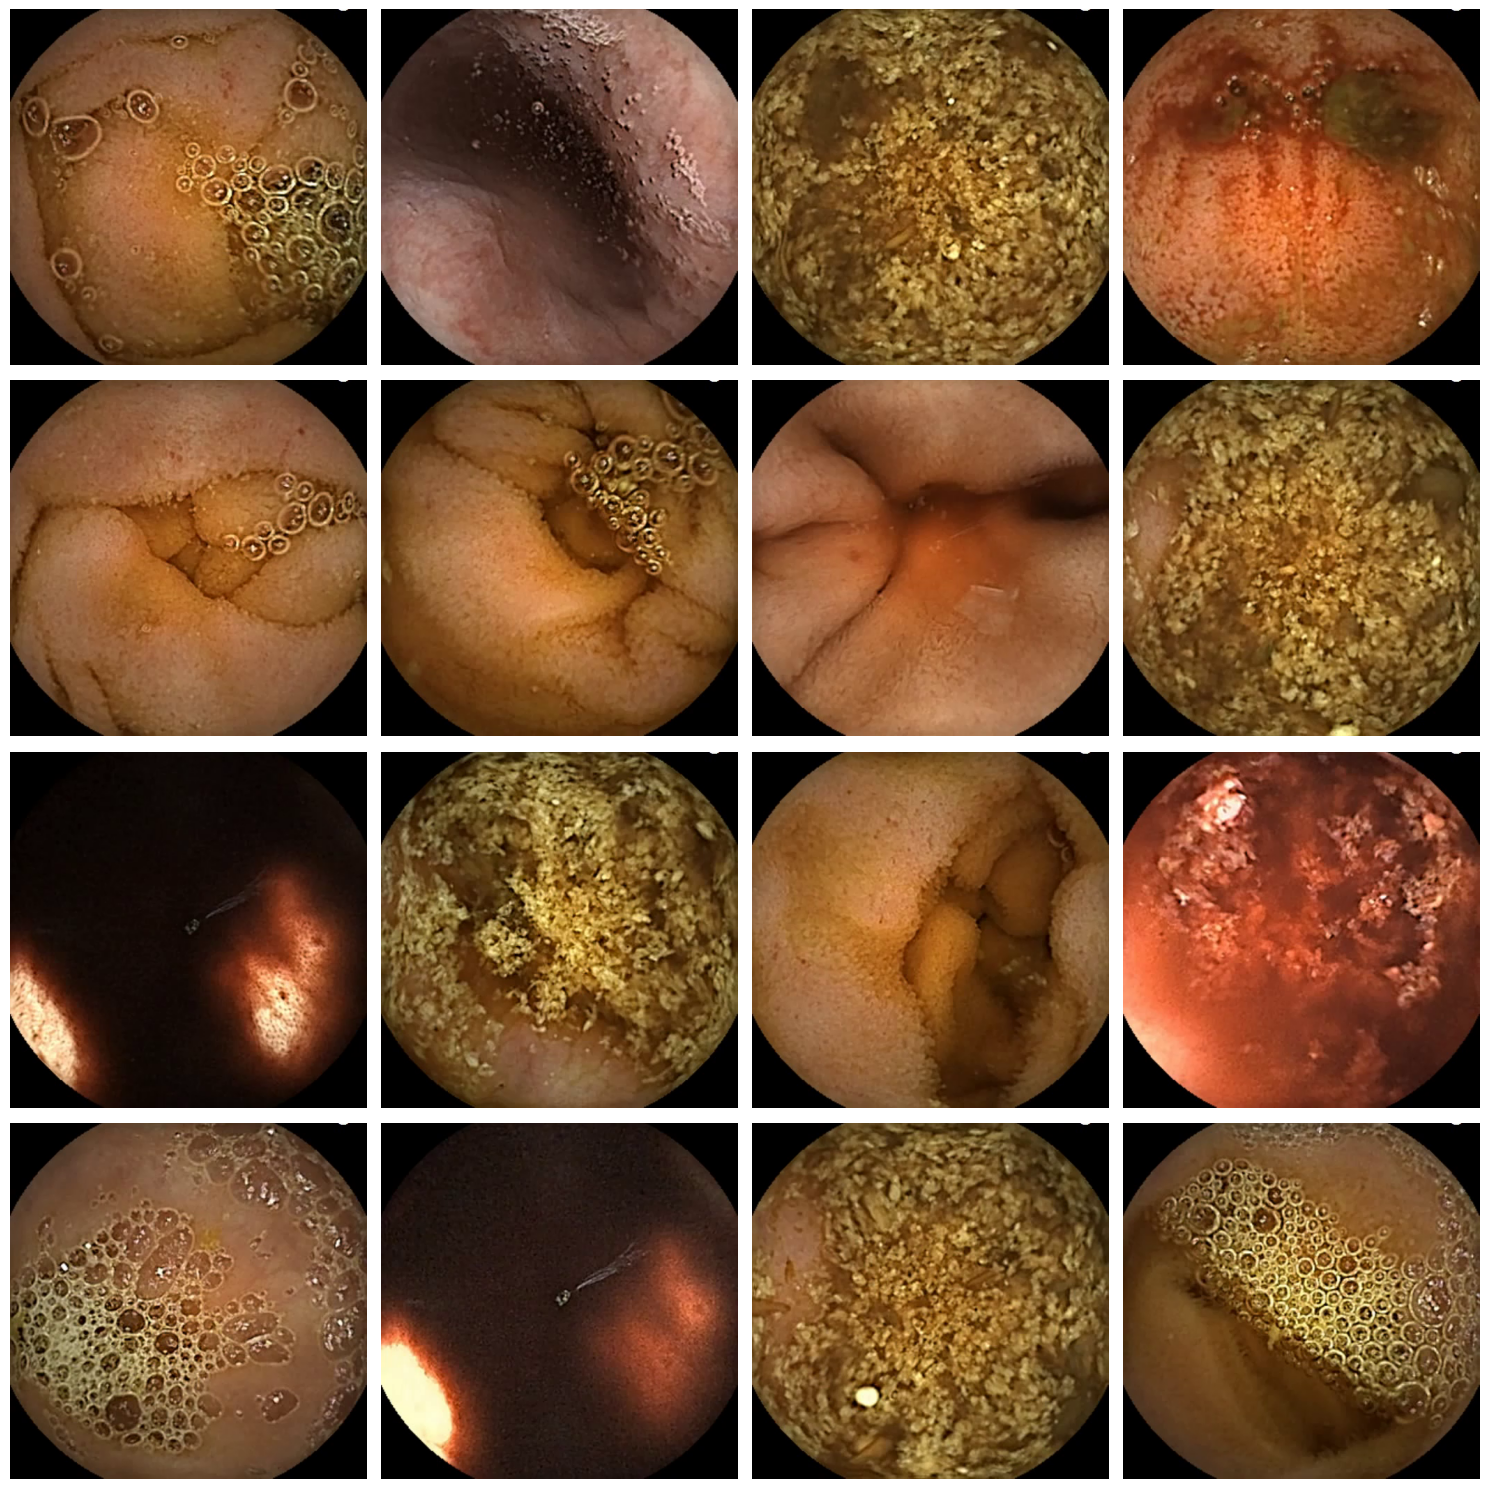

In [17]:
import matplotlib.pyplot as plt
import requests
import cv2

#fig = plt.figure(figsize = (15, 15))
random_idx = np.random.randint(1, len(test_paths),size = 16)
print('random_idx=',random_idx)
fig, axes = plt.subplots(4, 4, figsize=(15, 15))

#for i, url in enumerate(urls):
#for i in range (30):
for idx, ax in enumerate(axes.ravel()):
   # print('idx=',idx)
    idx1 = random_idx[idx]
    img = Image.open(test_paths[idx1][0])
    #img = Image.open(train_list[idx])
    #ax.set_title(labels[idx])
    ax.imshow(img)
    ax.axis('off')
   # plt.subplot(331 + i)      # plt.subplot(331 + i)

    # prepare image for the model
    pixel_values = processor(img,return_tensors="pt").pixel_values.to(device)

    classes = ['mouth','esophagus','stomach','smallintestine','colon',
         'z_line','pylorus','ileocecalvalve','activebleeding','angiectasia',
        'blood','erosion','erythema','hematin','lymphangioectasis',
        'polyp','ulcer']

    # forward pass
    with torch.no_grad():
        outputs = model_save(pixel_values)
        logits = outputs.logits
    
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(logits.squeeze().cpu())
    #print(probs)
    preds = zip(classes, list(probs))
    preds = sorted(list(preds), key = lambda z: z[1], reverse = True)[:3]

    print('preds=',preds)
   # print('Truth=',test_labels[idx1])

   # image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    # Showing image
  #  plt.imshow(image[:, :, ::-1])
  #  plt.title(f'{preds[0][0]}: {round(preds[0][1].item() * 100, 2)}% \n {preds[1][0]}: {round(preds[1][1].item() * 100, 2)}%')

plt.tight_layout()

In [ ]:
#Pairing elements from two lists into tuples and converts them into a 2D array.